# Lab 3 — Oscillator Simulation

**Name:** James Kurschner  
**Date:** September 13, 2026

This notebook compares Euler and Euler-Cromer integration for a harmonic oscillator, explores phase space and damping, and then studies a driven oscillator and resonance. The optional nonlinear-pendulum bonus is included at the end.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots a little easier to read.
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## Part A — The Simple Harmonic Oscillator

For a mass on a spring,

\[
F=-kx,\qquad a=-\frac{k}{m}x=-\omega_0^2x,
\]

where \(\omega_0=\sqrt{k/m}\). With \(k=m=1\), the natural angular frequency is \(\omega_0=1\) rad/s and the period is \(T=2\pi\).

The initial conditions are \(x(0)=1\) and \(v(0)=0\), so the exact solution is

\[
x(t)=\cos(t).
\]


In [2]:
def simulate_sho(method, dt, n_periods=10):
    k = 1.0
    m = 1.0
    x0 = 1.0
    v0 = 0.0

    omega0 = np.sqrt(k / m)
    T = 2 * np.pi / omega0
    t_max = n_periods * T

    n_steps = int(np.ceil(t_max / dt))
    t = np.arange(n_steps + 1) * dt

    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    E = np.zeros(n_steps + 1)

    x[0] = x0
    v[0] = v0
    E[0] = 0.5 * k * x[0]**2 + 0.5 * m * v[0]**2

    for i in range(n_steps):
        a = -(k / m) * x[i]

        if method == "euler":
            # Standard Euler: position uses the old velocity.
            x[i + 1] = x[i] + v[i] * dt
            v[i + 1] = v[i] + a * dt

        elif method == "euler-cromer":
            # Euler-Cromer: update velocity first, then position.
            v[i + 1] = v[i] + a * dt
            x[i + 1] = x[i] + v[i + 1] * dt

        else:
            raise ValueError("method must be 'euler' or 'euler-cromer'")

        E[i + 1] = 0.5 * k * x[i + 1]**2 + 0.5 * m * v[i + 1]**2

    return t, x, v, E


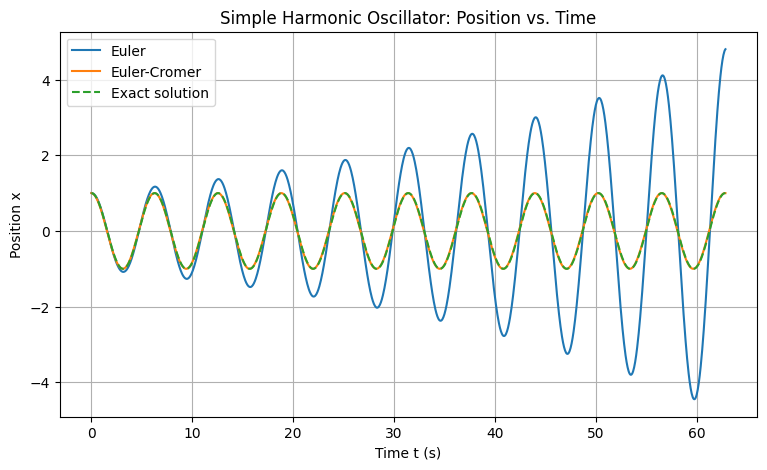

In [3]:
dt = 0.05

t_e, x_e, v_e, E_e = simulate_sho("euler", dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho("euler-cromer", dt)

x_exact = np.cos(t_e)

plt.plot(t_e, x_e, label="Euler")
plt.plot(t_ec, x_ec, label="Euler-Cromer")
plt.plot(t_e, x_exact, "--", label="Exact solution")
plt.xlabel("Time t (s)")
plt.ylabel("Position x")
plt.title("Simple Harmonic Oscillator: Position vs. Time")
plt.legend()
plt.show()


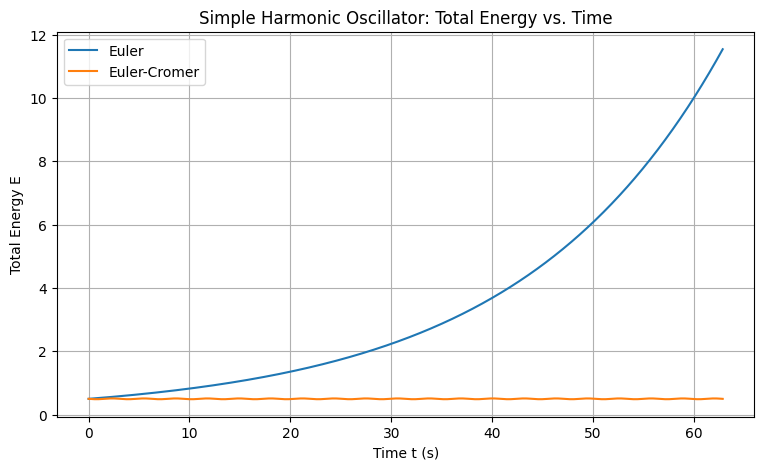

Euler:       E_initial = 0.500, E_final = 11.536
Euler-Cromer: E_initial = 0.500, E_final = 0.499


In [4]:
plt.plot(t_e, E_e, label="Euler")
plt.plot(t_ec, E_ec, label="Euler-Cromer")
plt.xlabel("Time t (s)")
plt.ylabel("Total Energy E")
plt.title("Simple Harmonic Oscillator: Total Energy vs. Time")
plt.legend()
plt.show()

print(f"Euler:       E_initial = {E_e[0]:.3f}, E_final = {E_e[-1]:.3f}")
print(f"Euler-Cromer: E_initial = {E_ec[0]:.3f}, E_final = {E_ec[-1]:.3f}")


### Part A Interpretation

The standard Euler solution develops a larger and larger amplitude over the 10 periods instead of staying at a constant amplitude. Its total energy also grows strongly, from about 0.5 initially to about 11.5 by the end, even though no physical source is adding energy. Euler-Cromer does not show this runaway behavior: its amplitude stays close to 1 and its energy only oscillates slightly around the correct value instead of drifting upward.


## Part B — Phase Space and Damped Oscillations

### B.1 — Phase-Space Portraits

A phase-space portrait plots velocity \(v\) against position \(x\). For an ideal undamped oscillator with conserved energy, the trajectory should remain a closed loop.


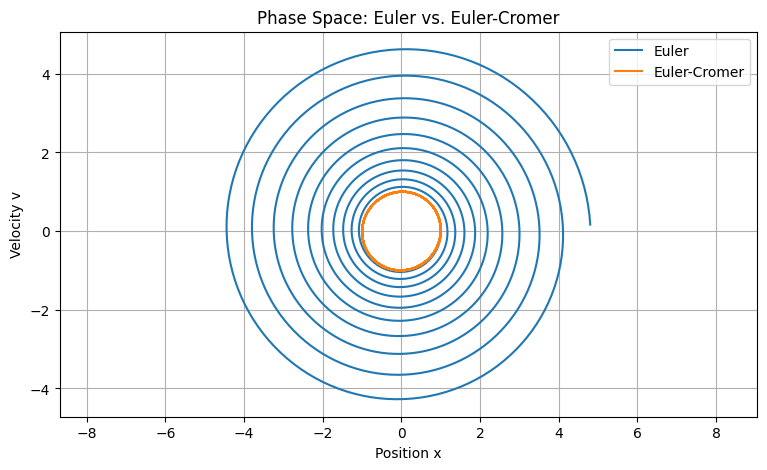

In [5]:
plt.plot(x_e, v_e, label="Euler")
plt.plot(x_ec, v_ec, label="Euler-Cromer")
plt.xlabel("Position x")
plt.ylabel("Velocity v")
plt.title("Phase Space: Euler vs. Euler-Cromer")
plt.legend()
plt.axis("equal")
plt.show()


The Euler trajectory spirals outward in phase space because the numerical method continually adds energy to the oscillator. The Euler-Cromer trajectory stays close to a closed ellipse, which matches the bounded energy seen in the energy plot and shows that it preserves the oscillator's qualitative behavior much better.


### B.2 — Damped Oscillations

The damped equation of motion is

\[
a=-\frac{k}{m}x-\frac{b}{m}v.
\]

For \(k=m=1\), the damping ratio is \(\zeta=b/2\). Therefore:

- \(b=0.2\) gives \(\zeta=0.1\): underdamped
- \(b=2.0\) gives \(\zeta=1\): critically damped
- \(b=4.0\) gives \(\zeta=2\): overdamped


In [6]:
def simulate_damped(b, dt=0.01, n_periods=10):
    k = 1.0
    m = 1.0
    x0 = 1.0
    v0 = 0.0

    omega0 = np.sqrt(k / m)
    T = 2 * np.pi / omega0
    t_max = n_periods * T

    n_steps = int(np.ceil(t_max / dt))
    t = np.arange(n_steps + 1) * dt

    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0] = x0
    v[0] = v0

    for i in range(n_steps):
        a = -(k / m) * x[i] - (b / m) * v[i]

        # Euler-Cromer
        v[i + 1] = v[i] + a * dt
        x[i + 1] = x[i] + v[i + 1] * dt

    return t, x, v


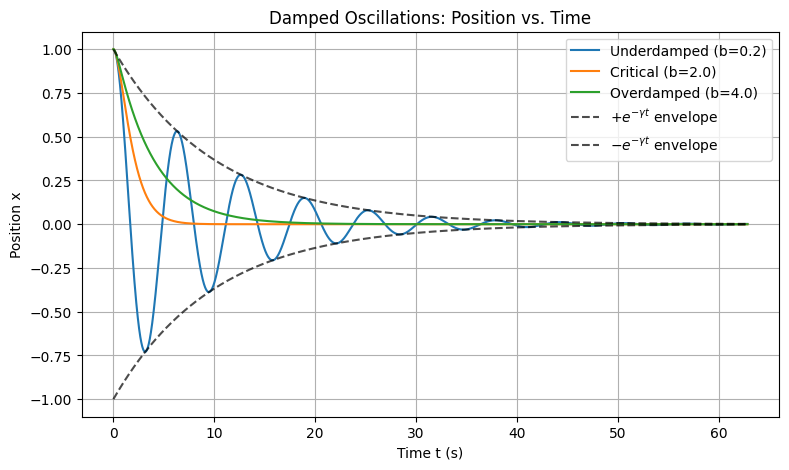

In [7]:
damping_cases = {
    "Underdamped (b=0.2)": 0.2,
    "Critical (b=2.0)": 2.0,
    "Overdamped (b=4.0)": 4.0,
}

damped_results = {}

for label, b in damping_cases.items():
    damped_results[label] = simulate_damped(b)

plt.figure()
for label, (t, x, v) in damped_results.items():
    plt.plot(t, x, label=label)

# Optional theoretical decay envelope for the underdamped case.
t_u, x_u, v_u = damped_results["Underdamped (b=0.2)"]
gamma = 0.2 / (2 * 1.0)
envelope = np.exp(-gamma * t_u)
plt.plot(t_u, envelope, "k--", alpha=0.7, label=r"$+e^{-\gamma t}$ envelope")
plt.plot(t_u, -envelope, "k--", alpha=0.7, label=r"$-e^{-\gamma t}$ envelope")

plt.xlabel("Time t (s)")
plt.ylabel("Position x")
plt.title("Damped Oscillations: Position vs. Time")
plt.legend()
plt.show()


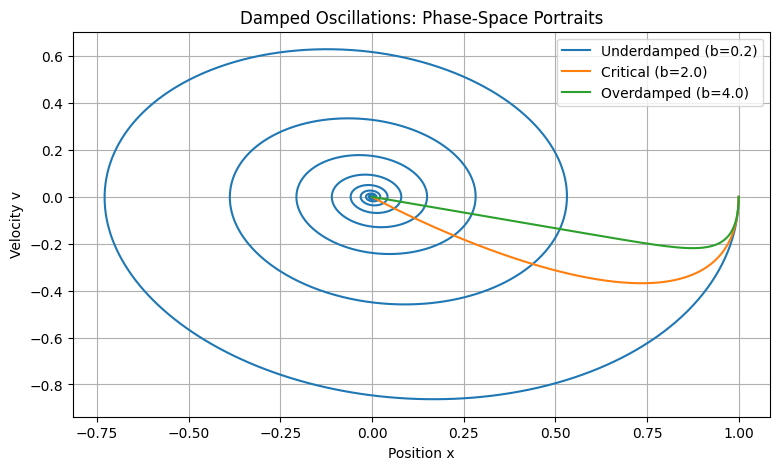

In [8]:
plt.figure()
for label, (t, x, v) in damped_results.items():
    plt.plot(x, v, label=label)

plt.xlabel("Position x")
plt.ylabel("Velocity v")
plt.title("Damped Oscillations: Phase-Space Portraits")
plt.legend()
plt.show()


### Part B Interpretation

The underdamped oscillator spirals into the origin while continuing to circle it many times, because it keeps oscillating as its energy is gradually removed by damping. The critically damped case approaches the origin without repeated oscillations and returns to equilibrium quickly. The overdamped case also approaches the origin without oscillating, but it does so more slowly because the large damping force strongly resists the motion.


## Part C — Driven Oscillations and Resonance

The driven, damped equation is

\[
a=-\frac{k}{m}x-\frac{b}{m}v+\frac{F_0}{m}\cos(\omega_d t).
\]

Here \(k=m=1\), \(b=0.2\), and \(F_0=1.0\), so the natural angular frequency is \(\omega_0=1\) rad/s.


In [9]:
def simulate_driven(omega_d, b=0.2, F0=1.0, k=1.0, m=1.0,
                    dt=0.02, n_periods=40, x0=0.0, v0=0.0):
    omega0 = np.sqrt(k / m)
    T0 = 2 * np.pi / omega0
    t_max = n_periods * T0

    n_steps = int(np.ceil(t_max / dt))
    t = np.arange(n_steps + 1) * dt

    x = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    x[0] = x0
    v[0] = v0

    for i in range(n_steps):
        a = (-(k / m) * x[i]
             - (b / m) * v[i]
             + (F0 / m) * np.cos(omega_d * t[i]))

        # Euler-Cromer
        v[i + 1] = v[i] + a * dt
        x[i + 1] = x[i] + v[i + 1] * dt

    return t, x, v


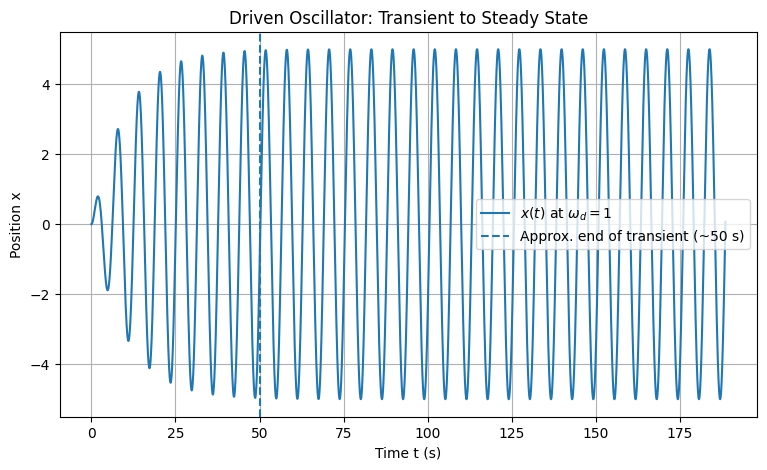

In [10]:
# Transient -> steady state at resonance
omega_d = 1.0
t_r, x_r, v_r = simulate_driven(omega_d, n_periods=30)

# The transient decays roughly as exp(-gamma*t), gamma=b/(2m)=0.1.
# Five decay times is about 50 s, so use that as a visual guide.
transient_end = 50.0

plt.plot(t_r, x_r, label=r"$x(t)$ at $\omega_d=1$")
plt.axvline(transient_end, linestyle="--",
            label="Approx. end of transient (~50 s)")
plt.xlabel("Time t (s)")
plt.ylabel("Position x")
plt.title("Driven Oscillator: Transient to Steady State")
plt.legend()
plt.show()


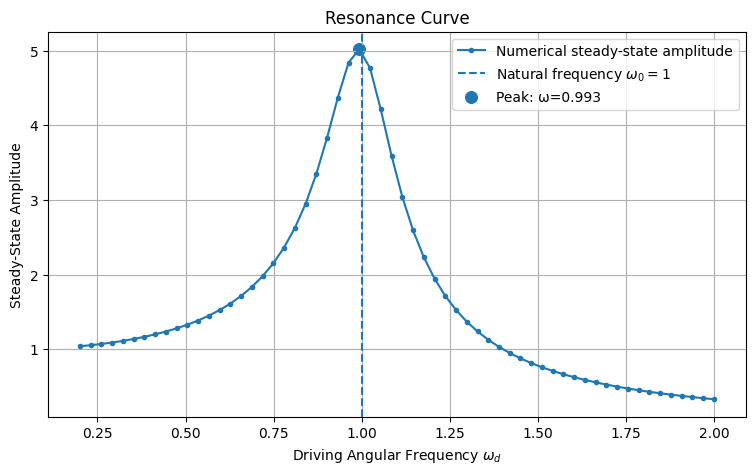

Peak driving frequency = 0.9932 rad/s
Peak steady-state amplitude = 5.0192
Natural frequency omega_0 = 1.0000 rad/s


In [11]:
# Resonance curve: sweep the driving frequency from 0.2 to 2.0.
omega_values = np.linspace(0.2, 2.0, 60)
amplitudes = []

for omega_d in omega_values:
    t, x, v = simulate_driven(omega_d, n_periods=40)

    # Keep only the last 30% so the transient is discarded.
    tail = x[int(0.7 * len(x)):]
    amplitude = np.max(np.abs(tail))
    amplitudes.append(amplitude)

amplitudes = np.array(amplitudes)

peak_index = np.argmax(amplitudes)
peak_omega = omega_values[peak_index]
peak_amplitude = amplitudes[peak_index]

plt.plot(omega_values, amplitudes, "o-", markersize=3,
         label="Numerical steady-state amplitude")
plt.axvline(1.0, linestyle="--", label=r"Natural frequency $\omega_0=1$")
plt.scatter([peak_omega], [peak_amplitude], s=70,
            label=f"Peak: ω={peak_omega:.3f}")
plt.xlabel(r"Driving Angular Frequency $\omega_d$")
plt.ylabel("Steady-State Amplitude")
plt.title("Resonance Curve")
plt.legend()
plt.show()

print(f"Peak driving frequency = {peak_omega:.4f} rad/s")
print(f"Peak steady-state amplitude = {peak_amplitude:.4f}")
print("Natural frequency omega_0 = 1.0000 rad/s")


### Part C Interpretation

The resonance curve reaches its largest amplitude at a driving frequency of about \(\omega_d=0.99\) rad/s, which is extremely close to the natural frequency \(\omega_0=1\) rad/s. The amplitude becomes large near this frequency because the driving force repeatedly adds energy in step with the oscillator's motion, so energy transfer is especially efficient. The peak is slightly below \(\omega_0\) because damping shifts the displacement-resonance frequency downward. If the damping were reduced, less energy would be lost during each cycle, so the resonance peak would become taller and narrower.


## Bonus — Nonlinear Pendulum

For the full pendulum,

\[
	heta''=-\frac{g}{L}\sin	heta.
\]

The small-angle approximation replaces \(\sin	heta\) with \(	heta\), predicting a period

\[
T_0=2\pi\sqrt{L/g}.
\]

The simulation below measures the period directly for several starting amplitudes.


In [12]:
def simulate_pendulum(theta0_deg, L=1.0, g=9.81, dt=0.001, t_max=30.0):
    theta0 = np.radians(theta0_deg)

    n_steps = int(np.ceil(t_max / dt))
    t = np.arange(n_steps + 1) * dt
    theta = np.zeros(n_steps + 1)
    omega = np.zeros(n_steps + 1)

    theta[0] = theta0
    omega[0] = 0.0

    for i in range(n_steps):
        alpha = -(g / L) * np.sin(theta[i])

        # Euler-Cromer
        omega[i + 1] = omega[i] + alpha * dt
        theta[i + 1] = theta[i] + omega[i + 1] * dt

    return t, theta, omega


def measure_period(theta0_deg, L=1.0, g=9.81, dt=0.001, t_max=30.0):
    t, theta, omega = simulate_pendulum(theta0_deg, L, g, dt, t_max)

    # Record downward zero crossings. Consecutive downward crossings
    # are separated by one full period.
    crossing_times = []

    for i in range(len(theta) - 1):
        if theta[i] > 0 and theta[i + 1] <= 0:
            # Linear interpolation improves the crossing-time estimate.
            fraction = theta[i] / (theta[i] - theta[i + 1])
            crossing_time = t[i] + fraction * dt
            crossing_times.append(crossing_time)

    periods = np.diff(crossing_times)
    return np.mean(periods)


In [13]:
L = 1.0
g = 9.81
T_small_angle = 2 * np.pi * np.sqrt(L / g)

test_angles = [5, 30, 90, 150]
measured_periods = []

for angle in test_angles:
    T_num = measure_period(angle, L=L, g=g)
    measured_periods.append(T_num)
    percent_difference = 100 * (T_num - T_small_angle) / T_small_angle
    print(f"{angle:>3} deg: T = {T_num:.4f} s, "
          f"difference from small-angle = {percent_difference:.2f}%")

print(f"Small-angle prediction: T0 = {T_small_angle:.4f} s")


  5 deg: T = 2.0070 s, difference from small-angle = 0.05%
 30 deg: T = 2.0410 s, difference from small-angle = 1.74%


 90 deg: T = 2.3678 s, difference from small-angle = 18.03%


150 deg: T = 3.5351 s, difference from small-angle = 76.22%
Small-angle prediction: T0 = 2.0061 s


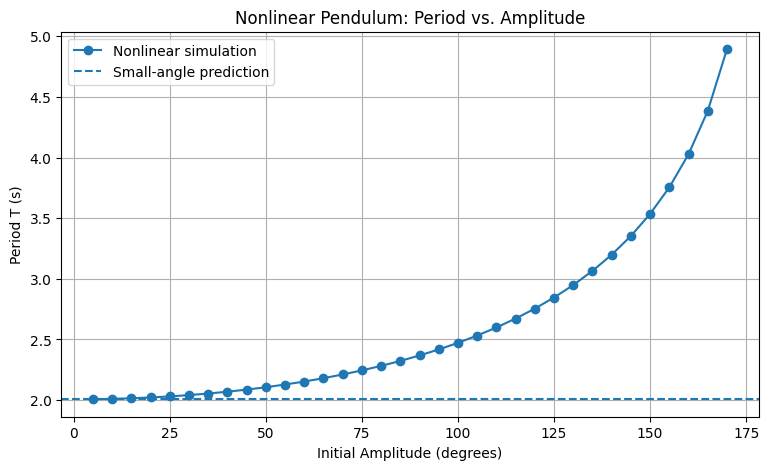

In [14]:
# Use a denser set of amplitudes for the period-vs-amplitude graph.
angle_values = np.linspace(5, 170, 34)
period_values = np.array([measure_period(angle) for angle in angle_values])

plt.plot(angle_values, period_values, "o-", label="Nonlinear simulation")
plt.axhline(T_small_angle, linestyle="--", label="Small-angle prediction")
plt.xlabel("Initial Amplitude (degrees)")
plt.ylabel("Period T (s)")
plt.title("Nonlinear Pendulum: Period vs. Amplitude")
plt.legend()
plt.show()


### Bonus Interpretation

At \(5^\circ\), the numerical period is essentially the same as the small-angle prediction, differing by only about 0.05%. At \(30^\circ\) the period is already about 1.7% longer, while at \(90^\circ\) it is about 18% longer and at \(150^\circ\) it is roughly 76% longer. This shows that the small-angle approximation works very well for small oscillations but begins to miss the real period by more than a few percent once the amplitude reaches roughly a few tens of degrees.


## Final Check

All required parts are included:

- Part A: `simulate_sho`, position comparison, energy comparison, interpretation
- Part B: phase-space comparison, damped simulator, all three damping regimes, interpretations
- Part C: driven simulator, transient-to-steady-state plot, resonance curve, peak identification, interpretation
- Bonus: nonlinear pendulum and period-vs-amplitude study

Before submitting, restart the kernel and run all cells from top to bottom to confirm the notebook executes cleanly.
